# 🌎 Dashboard: Tipo de Cambio Real Bilateral (TCRB) — Competitividad Turística de Chile

## Objetivo
Analizar la **competitividad turística de Chile** frente a Brasil y Perú, tanto desde la perspectiva **emisiva** (chilenos viajando al exterior) como **receptiva** (extranjeros visitando Chile).

## Metodología
La fórmula central del Tipo de Cambio Real Bilateral es:

$$TCRB = \frac{E \cdot P_i}{P_{CL}}$$

| Variable | Descripción |
|----------|-------------|
| $E$ | Tipo de cambio nominal (ej: CLP por 1 BRL) |
| $P_i$ | IPC del país de destino (índice base) |
| $P_{CL}$ | IPC de Chile (índice base) |

### Interpretación
- **Perspectiva Emisiva** (Chileno viajando): Si el TCRB **sube**, el destino se **encarece** relativamente → Chile gana competitividad como destino.
- **Perspectiva Receptiva** (Extranjero viajando a Chile): Se usa $1/TCRB$. Si sube, Chile se **encarece** para el turista extranjero.

### Fuentes de Datos
| Dato | Fuente | Serie |
|------|--------|-------|
| FX BRL/CLP | Yahoo Finance | `BRLCLP=X` |
| FX PEN → CLP | Yahoo Finance | `PENUSD=X` × `CLP=X` (cross-rate) |
| IPC Chile | FRED (OECD) | `CHLCPIALLMINMEI` |
| IPC Brasil | FRED (OECD) | `BRACPIALLMINMEI` |
| IPC Perú | FRED (OECD) | `PERCPIALLMINMEI` |

> **Nota:** Se prepara la arquitectura para integrar la API del Banco Central de Chile como fuente primaria oficial.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 1: Instalación de dependencias e imports
# ══════════════════════════════════════════════════════════════
!pip install yfinance pandas_datareader ipywidgets matplotlib -q

import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

# ── Configuración Global ──────────────────────────────────────
FECHA_INICIO = '2000-01-01'
FECHA_FIN = datetime.today().strftime('%Y-%m-%d')
MAX_REINTENTOS = 3
PAUSA_REINTENTO = 2  # segundos

# Paleta de colores profesional
COLORES = {
    'Brasil': {'primario': '#009C3B', 'secundario': '#FFDF00', 'fondo': '#E8F5E9'},
    'Perú':   {'primario': '#D91023', 'secundario': '#C8102E', 'fondo': '#FFEBEE'},
    'Chile':  {'primario': '#0039A6', 'secundario': '#D52B1E', 'fondo': '#E3F2FD'},
    'neutro': '#555555',
    'equilibrio': '#333333',
    'favorable': '#4CAF50',
    'desfavorable': '#F44336',
    'grid': '#E0E0E0',
}

# Configuración de países (arquitectura extensible)
PAISES_CONFIG = {
    'Brasil': {
        'moneda': 'BRL',
        'fx_ticker_directo': 'BRLCLP=X',           # BRL → CLP directo
        'fx_ticker_cross': ('BRLUSD=X', 'CLP=X'),   # fallback vía USD
        'ipc_fred_series': ['BRACPIALLMINMEI'],
        'ipc_wb_code': 'FP.CPI.TOTL',
        'ipc_wb_country': 'BRA',
        'ipc_fred_inflacion_anual': 'FPCPITOTLZGBRA',
        'bandera': '🇧🇷',
    },
    'Perú': {
        'moneda': 'PEN',
        'fx_ticker_directo': None,                    # no existe directo
        'fx_ticker_cross': ('PENUSD=X', 'CLP=X'),    # siempre vía USD
        'ipc_fred_series': ['PERCPIALLMINMEI', 'PERCPIALLQINMEI'],
        'ipc_wb_code': 'FP.CPI.TOTL',                # World Bank: CPI (2010=100)
        'ipc_wb_country': 'PER',
        'ipc_fred_inflacion_anual': 'FPCPITOTLZGPER', # Fallback 3: inflación anual → IPC sintético
        'bandera': '🇵🇪',
    },
}

IPC_CHILE_SERIES = ['CHLCPIALLMINMEI']

print("✅ Librerías importadas y configuración cargada.")
print(f"   Rango de análisis: {FECHA_INICIO} → {FECHA_FIN}")
print(f"   Países configurados: {', '.join(PAISES_CONFIG.keys())}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.3 MB/s eta 0:00:00
✅ Librerías importadas y configuración cargada.
   Rango de análisis: 2000-01-01 → 2026-03-24
   Países configurados: Brasil, Perú


## 1. Funciones Auxiliares
Módulos reutilizables para descarga con reintentos, validación y cálculo del TCRB.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 2: Funciones auxiliares robustas
# ══════════════════════════════════════════════════════════════

def descargar_con_reintentos(func, *args, intentos=MAX_REINTENTOS, **kwargs):
    """Ejecuta una función de descarga con reintentos y backoff exponencial."""
    for i in range(intentos):
        try:
            resultado = func(*args, **kwargs)
            if resultado is not None and not (hasattr(resultado, 'empty') and resultado.empty):
                return resultado
        except Exception as e:
            if i < intentos - 1:
                espera = PAUSA_REINTENTO * (2 ** i)
                print(f"   ⚠️  Intento {i+1}/{intentos} falló: {e}. Reintentando en {espera}s...")
                time.sleep(espera)
            else:
                print(f"   ❌ Todos los intentos fallaron para: {args}. Error: {e}")
    return None


def descargar_fx_yahoo(ticker, inicio, fin):
    """Descarga tipo de cambio desde Yahoo Finance y retorna serie mensual."""
    data = yf.download(ticker, start=inicio, end=fin, progress=False, timeout=15)
    if data is None or data.empty:
        return None
    close = data['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    mensual = close.resample('MS').mean()
    mensual.index = mensual.index.tz_localize(None)
    return mensual


def obtener_fx_pais(config, inicio, fin):
    """
    Obtiene el tipo de cambio MON/CLP para un país.
    Intenta primero el ticker directo; si falla, calcula cross-rate vía USD.
    """
    # Intento 1: Ticker directo
    if config.get('fx_ticker_directo'):
        print(f"   📊 Intentando ticker directo: {config['fx_ticker_directo']}")
        serie = descargar_con_reintentos(descargar_fx_yahoo,
                                          config['fx_ticker_directo'], inicio, fin)
        if serie is not None and not serie.empty and serie.notna().sum() > 10:
            print(f"   ✅ Ticker directo exitoso ({len(serie)} observaciones)")
            return serie

    # Intento 2: Cross-rate vía USD
    if config.get('fx_ticker_cross'):
        t1, t2 = config['fx_ticker_cross']
        print(f"   📊 Calculando cross-rate: {t1} × {t2}")
        s1 = descargar_con_reintentos(descargar_fx_yahoo, t1, inicio, fin)
        s2 = descargar_con_reintentos(descargar_fx_yahoo, t2, inicio, fin)

        if s1 is not None and s2 is not None:
            idx_comun = s1.index.intersection(s2.index)
            cross = s1.loc[idx_comun] * s2.loc[idx_comun]
            if isinstance(cross, pd.DataFrame):
                cross = cross.iloc[:, 0]
            if not cross.empty:
                print(f"   ✅ Cross-rate exitoso ({len(cross)} observaciones)")
                return cross

    print(f"   ❌ No se pudo obtener FX para {config['moneda']}/CLP")
    return None


def obtener_ipc_fred(lista_series, inicio, fin):
    """Intenta descargar IPC desde FRED, probando múltiples series alternativas."""
    for serie_id in lista_series:
        print(f"   📊 Intentando serie FRED: {serie_id}")
        def _descarga():
            return web.DataReader(serie_id, 'fred', inicio, fin)
        resultado = descargar_con_reintentos(_descarga)
        if resultado is not None and not resultado.empty:
            s = resultado.iloc[:, 0]
            s.index = s.index.map(lambda x: x.replace(day=1))
            ratio_validos = s.notna().mean()
            if ratio_validos >= 0.5:
                print(f"   ✅ Serie {serie_id} OK ({len(s)} obs, {ratio_validos:.0%} válidos)")
                return s
            else:
                print(f"   ⚠️  Serie {serie_id} tiene solo {ratio_validos:.0%} datos válidos")
    print(f"   ❌ Ninguna serie de IPC disponible")
    return None


def validar_dataframe(df, nombre_col, min_obs=24):
    """Valida que una columna tenga suficientes observaciones."""
    if nombre_col not in df.columns:
        return False, f"Columna '{nombre_col}' no encontrada"
    validos = df[nombre_col].notna().sum()
    if validos < min_obs:
        return False, f"'{nombre_col}' tiene solo {validos} obs válidas (mínimo: {min_obs})"
    return True, f"'{nombre_col}' OK con {validos} observaciones"


def calcular_tcrb(df, col_fx, col_ipc_ext, col_ipc_chl, base=100):
    """
    Calcula el TCRB y lo normaliza a un índice base.
    Retorna (serie_raw, serie_index) o (None, None) si falla.
    """
    mask = df[[col_fx, col_ipc_ext, col_ipc_chl]].notna().all(axis=1)
    if mask.sum() < 12:
        return None, None

    tcrb_raw = (df.loc[mask, col_fx] * df.loc[mask, col_ipc_ext]) / df.loc[mask, col_ipc_chl]

    # Normalización robusta: promedio del primer año como base
    primer_anio = tcrb_raw.index[0].year
    base_val = tcrb_raw[tcrb_raw.index.year == primer_anio].mean()
    if base_val == 0 or pd.isna(base_val):
        base_val = tcrb_raw.iloc[0]

    tcrb_index = (tcrb_raw / base_val) * base

    return tcrb_raw, tcrb_index

def construir_ipc_sintetico_desde_inflacion(serie_id, inicio, fin):
    """
    Construye un IPC mensual sintético a partir de la tasa de inflación anual de FRED.
    Descarga la serie anual (ej: FPCPITOTLZGPER = inflación % anual de Perú),
    la interpola a mensual y acumula un índice base 100.
    """
    print(f"   📊 Construyendo IPC sintético desde inflación anual: {serie_id}")
    def _descarga():
        return web.DataReader(serie_id, 'fred', inicio, fin)
    resultado = descargar_con_reintentos(_descarga)
    if resultado is None or resultado.empty:
        print(f"   ❌ No se pudo descargar {serie_id}")
        return None

    inflacion_anual = resultado.iloc[:, 0].dropna()  # % anual
    if len(inflacion_anual) < 5:
        print(f"   ❌ Muy pocos datos en {serie_id} ({len(inflacion_anual)} obs)")
        return None

    # Convertir tasa anual a tasa mensual: (1 + r_anual/100)^(1/12) - 1
    tasa_mensual_impl = (1 + inflacion_anual / 100) ** (1/12) - 1

    # Interpolar a frecuencia mensual
    tasa_mensual_impl.index = tasa_mensual_impl.index.map(lambda x: x.replace(day=1, month=1))
    idx_mensual = pd.date_range(start=tasa_mensual_impl.index.min(), end=fin, freq='MS')
    tasa_interpol = tasa_mensual_impl.reindex(idx_mensual).interpolate(method='linear').ffill().bfill()

    # Acumular para construir índice base 100
    ipc_sintetico = pd.Series(index=tasa_interpol.index, dtype=float)
    ipc_sintetico.iloc[0] = 100.0
    for i in range(1, len(ipc_sintetico)):
        ipc_sintetico.iloc[i] = ipc_sintetico.iloc[i-1] * (1 + tasa_interpol.iloc[i])

    ipc_sintetico.index = ipc_sintetico.index.map(lambda x: x.replace(day=1))

    ratio_validos = ipc_sintetico.notna().mean()
    print(f"   ✅ IPC sintético construido: {len(ipc_sintetico)} obs mensuales ({ratio_validos:.0%} válidos)")
    print(f"   ⚠️  Nota: Este IPC es una aproximación interpolada desde datos anuales")
    return ipc_sintetico


def obtener_ipc_worldbank(country_code, inicio, fin):
    """
    Fallback: Descarga IPC anual del World Bank (FP.CPI.TOTL, base 2010=100)
    y lo interpola a frecuencia mensual.
    """
    print(f"   📊 Fallback World Bank: FP.CPI.TOTL para {country_code}")
    try:
        import subprocess
        subprocess.check_call(['pip', 'install', 'wbgapi', '-q'],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        import wbgapi as wb

        anio_ini = int(inicio[:4])
        anio_fin = int(fin[:4])
        rango = range(anio_ini, anio_fin + 1)

        data = wb.data.DataFrame('FP.CPI.TOTL', economy=country_code, time=rango)

        if data is None or data.empty:
            print(f"   ❌ World Bank sin datos para {country_code}")
            return None

        vals = {}
        for col in data.columns:
            try:
                year = int(col.replace('YR', ''))
                val = data[col].iloc[0]
                if pd.notna(val):
                    vals[pd.Timestamp(f'{year}-07-01')] = float(val)
            except (ValueError, IndexError):
                continue

        if len(vals) < 5:
            print(f"   ❌ World Bank: solo {len(vals)} años con datos")
            return None

        serie_anual = pd.Series(vals).sort_index()
        idx_mensual = pd.date_range(
            start=serie_anual.index[0].replace(month=1, day=1),
            end=serie_anual.index[-1].replace(month=12, day=1),
            freq='MS'
        )
        serie_mensual = serie_anual.reindex(idx_mensual).interpolate(method='cubic')
        serie_mensual.index = serie_mensual.index.map(lambda x: x.replace(day=1))

        print(f"   ✅ World Bank IPC: {len(serie_mensual)} obs mensuales (interpoladas)")
        print(f"      ⚠️  Datos anuales interpolados a mensual — menor precisión que fuente directa")
        return serie_mensual

    except Exception as e:
        print(f"   ❌ Error World Bank: {e}")
        return None

print("✅ Funciones auxiliares definidas.")

✅ Funciones auxiliares definidas.


## 2. Extracción y Consolidación de Datos
Descarga tipos de cambio e IPC con manejo robusto de errores, reintentos y fallbacks.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 3: Descarga y consolidación de datos
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("DESCARGA DE DATOS")
print("=" * 60)

# ── 1. IPC de Chile (obligatorio) ─────────────────────────────
print("\n🇨🇱 IPC Chile:")
ipc_chile = obtener_ipc_fred(IPC_CHILE_SERIES, FECHA_INICIO, FECHA_FIN)
if ipc_chile is None:
    raise RuntimeError("❌ CRÍTICO: No se pudo obtener el IPC de Chile. Imposible calcular TCRB.")

# ── 2. Datos por país ─────────────────────────────────────────
datos_fx = {}
datos_ipc = {}
paises_validos = []

for pais, config in PAISES_CONFIG.items():
    print(f"\n{config['bandera']} {pais} ({config['moneda']}):")

    # Tipo de cambio
    print(f"  Tipo de cambio {config['moneda']}/CLP:")
    fx = obtener_fx_pais(config, FECHA_INICIO, FECHA_FIN)
    if fx is not None:
        datos_fx[pais] = fx

    # IPC
    print(f"  IPC {pais}:")
    ipc = obtener_ipc_fred(config['ipc_fred_series'], FECHA_INICIO, FECHA_FIN)

    # Fallback 1: World Bank (FP.CPI.TOTL) interpolado a mensual
    if ipc is None and config.get('ipc_wb_code'):
        print(f"  ⚠️  FRED falló. Intentando World Bank...")
        ipc = obtener_ipc_worldbank(config['ipc_wb_country'], FECHA_INICIO, FECHA_FIN)

    # Fallback 2: IPC sintético desde inflación anual FRED
    if ipc is None and config.get('ipc_fred_inflacion_anual'):
        print(f"  ⚠️  World Bank falló. Construyendo IPC sintético...")
        ipc = construir_ipc_sintetico_desde_inflacion(
            config['ipc_fred_inflacion_anual'], FECHA_INICIO, FECHA_FIN
        )

    if ipc is not None:
        datos_ipc[pais] = ipc

    # Validar disponibilidad completa
    if pais in datos_fx and pais in datos_ipc:
        paises_validos.append(pais)
        print(f"  ✅ {pais}: datos completos")
    else:
        faltante = []
        if pais not in datos_fx: faltante.append("FX")
        if pais not in datos_ipc: faltante.append("IPC")
        print(f"  ⚠️  {pais}: faltan datos de {', '.join(faltante)}")

# ── 3. Consolidar DataFrame ──────────────────────────────────
print("\n" + "=" * 60)
print("CONSOLIDACIÓN")
print("=" * 60)

# Crear índice maestro mensual
todos_indices = [ipc_chile.index]
for p in paises_validos:
    todos_indices.append(datos_fx[p].index)
    todos_indices.append(datos_ipc[p].index)

idx_union = sorted(set().union(*[set(idx) for idx in todos_indices]))
df = pd.DataFrame(index=pd.DatetimeIndex(idx_union, freq='MS'))

# Insertar IPC Chile
df['IPC_CHL'] = ipc_chile

# Insertar datos por país
for pais in paises_validos:
    df[f'FX_{pais}'] = datos_fx[pais]
    df[f'IPC_{pais}'] = datos_ipc[pais]

# Forward-fill para pequeños gaps (máximo 3 meses)
df = df.ffill(limit=3)

# Reporte de calidad
print("\n📋 Reporte de Calidad de Datos:")
print(f"   Rango temporal: {df.index.min().strftime('%Y-%m')} → {df.index.max().strftime('%Y-%m')}")
print(f"   Total meses: {len(df)}")
print(f"   Países válidos: {', '.join(paises_validos) if paises_validos else 'NINGUNO'}")

for col in df.columns:
    n_validos = df[col].notna().sum()
    pct = n_validos / len(df) * 100
    first_valid = df[col].first_valid_index()
    last_valid = df[col].last_valid_index()
    rango = f"{first_valid.strftime('%Y-%m')} → {last_valid.strftime('%Y-%m')}" if first_valid else "SIN DATOS"
    estado = "✅" if pct > 80 else "⚠️" if pct > 50 else "❌"
    print(f"   {estado} {col:20s}: {n_validos:4d} obs ({pct:5.1f}%) | {rango}")

if not paises_validos:
    raise RuntimeError("❌ CRÍTICO: No hay datos suficientes para ningún país.")

DESCARGA DE DATOS

🇨🇱 IPC Chile:
   📊 Intentando serie FRED: CHLCPIALLMINMEI
   ✅ Serie CHLCPIALLMINMEI OK (288 obs, 100% válidos)

🇧🇷 Brasil (BRL):
  Tipo de cambio BRL/CLP:
   📊 Intentando ticker directo: BRLCLP=X
   ✅ Ticker directo exitoso (249 observaciones)
  IPC Brasil:
   📊 Intentando serie FRED: BRACPIALLMINMEI
   ✅ Serie BRACPIALLMINMEI OK (304 obs, 100% válidos)
  ✅ Brasil: datos completos

🇵🇪 Perú (PEN):
  Tipo de cambio PEN/CLP:
   📊 Calculando cross-rate: PENUSD=X × CLP=X
   ✅ Cross-rate exitoso (268 observaciones)
  IPC Perú:
   📊 Intentando serie FRED: PERCPIALLMINMEI
   ⚠️  Intento 1/3 falló: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=PERCPIALLMINMEI
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="des

## 3. Integración con API del Banco Central de Chile (Opcional)
Este módulo permite reemplazar las fuentes Yahoo Finance / FRED con datos oficiales del BCCh. Requiere credenciales (usuario y contraseña) que se obtienen registrándose en [si.bcentral.cl](https://si.bcentral.cl/). Si no se proporcionan credenciales, el notebook sigue funcionando con las fuentes ya descargadas.

**Series disponibles en BCCh:**
| Código | Descripción |
|--------|-------------|
| `F073.TCO.PRE.Z.D` | Dólar Observado (diario) |
| `F072.CLP.EUR.N.O.D` | Euro/CLP (diario) |
| `F072.CLP.BRL.N.O.D` | Real/CLP (diario) |
| `F074.IPC.IND.Z.EP09.C.M` | IPC Chile mensual (base 2009) |

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 11: Integración API Banco Central de Chile (Opcional)
# ══════════════════════════════════════════════════════════════
# Para activar: ingresa tus credenciales en las variables de abajo.
# Si se dejan vacías, el notebook usa los datos ya descargados (FRED/Yahoo).

BCCH_USER = ""   # ← Tu usuario de si.bcentral.cl
BCCH_PASS = ""   # ← Tu contraseña

# Series del BCCh a consultar
BCCH_SERIES = {
    'dolar_obs': 'F073.TCO.PRE.Z.D',          # Dólar observado diario
    'brl_clp':   'F072.CLP.BRL.N.O.D',        # Real brasileño / CLP diario
    'ipc_chile': 'F074.IPC.IND.Z.EP09.C.M',   # IPC Chile mensual
}

bcch_disponible = False

if BCCH_USER and BCCH_PASS:
    try:
        import subprocess
        subprocess.check_call(['pip', 'install', 'bcch', '-q'])
        from bcch import Siete

        print("🏦 Conectando con API del Banco Central de Chile...")
        siete = Siete(BCCH_USER, BCCH_PASS)

        # ── Dólar Observado ───────────────────────────────────
        print("   📊 Descargando Dólar Observado...")
        try:
            usd_clp_bcch = siete.get_series(
                BCCH_SERIES['dolar_obs'],
                FECHA_INICIO,
                FECHA_FIN
            )
            if usd_clp_bcch is not None and not usd_clp_bcch.empty:
                usd_clp_bcch = usd_clp_bcch.iloc[:, 0].astype(float)
                usd_clp_bcch_mensual = usd_clp_bcch.resample('MS').mean()
                print(f"   ✅ Dólar Observado BCCh: {len(usd_clp_bcch_mensual)} obs mensuales")
                bcch_disponible = True
            else:
                print("   ⚠️  Dólar Observado sin datos")
        except Exception as e:
            print(f"   ❌ Error Dólar Observado: {e}")

        # ── BRL/CLP directo BCCh ──────────────────────────────
        print("   📊 Descargando BRL/CLP...")
        try:
            brl_clp_bcch = siete.get_series(
                BCCH_SERIES['brl_clp'],
                FECHA_INICIO,
                FECHA_FIN
            )
            if brl_clp_bcch is not None and not brl_clp_bcch.empty:
                brl_clp_bcch = brl_clp_bcch.iloc[:, 0].astype(float)
                brl_clp_bcch_mensual = brl_clp_bcch.resample('MS').mean()
                print(f"   ✅ BRL/CLP BCCh: {len(brl_clp_bcch_mensual)} obs mensuales")

                # Comparar con Yahoo Finance si existe
                if 'FX_Brasil' in df.columns:
                    comun = df['FX_Brasil'].dropna().index.intersection(brl_clp_bcch_mensual.index)
                    if len(comun) > 12:
                        corr = df.loc[comun, 'FX_Brasil'].corr(brl_clp_bcch_mensual.loc[comun])
                        diff_pct = ((df.loc[comun, 'FX_Brasil'] - brl_clp_bcch_mensual.loc[comun]) /
                                    brl_clp_bcch_mensual.loc[comun]).abs().mean() * 100
                        print(f"   📐 Validación cruzada Yahoo vs BCCh:")
                        print(f"      Correlación: {corr:.4f}")
                        print(f"      Diferencia media: {diff_pct:.2f}%")

                        # Reemplazar con fuente oficial si la correlación es alta
                        if corr > 0.95:
                            df['FX_Brasil_Yahoo'] = df['FX_Brasil'].copy()
                            df.loc[brl_clp_bcch_mensual.index, 'FX_Brasil'] = brl_clp_bcch_mensual
                            df['FX_Brasil'] = df['FX_Brasil'].ffill(limit=3)
                            print("   🔄 FX Brasil reemplazado con fuente BCCh (respaldo en FX_Brasil_Yahoo)")
            else:
                print("   ⚠️  BRL/CLP sin datos en BCCh")
        except Exception as e:
            print(f"   ❌ Error BRL/CLP: {e}")

        # ── IPC Chile BCCh ────────────────────────────────────
        print("   📊 Descargando IPC Chile BCCh...")
        try:
            ipc_chl_bcch = siete.get_series(
                BCCH_SERIES['ipc_chile'],
                FECHA_INICIO,
                FECHA_FIN
            )
            if ipc_chl_bcch is not None and not ipc_chl_bcch.empty:
                ipc_chl_bcch = ipc_chl_bcch.iloc[:, 0].astype(float)
                ipc_chl_bcch.index = ipc_chl_bcch.index.map(lambda x: x.replace(day=1))
                print(f"   ✅ IPC Chile BCCh: {len(ipc_chl_bcch)} obs mensuales")

                # Validación cruzada con FRED
                comun = df['IPC_CHL'].dropna().index.intersection(ipc_chl_bcch.index)
                if len(comun) > 12:
                    corr = df.loc[comun, 'IPC_CHL'].corr(ipc_chl_bcch.loc[comun])
                    print(f"   📐 Correlación IPC FRED vs BCCh: {corr:.4f}")
            else:
                print("   ⚠️  IPC Chile sin datos en BCCh")
        except Exception as e:
            print(f"   ❌ Error IPC Chile BCCh: {e}")

        if bcch_disponible:
            print("\n🏦 ✅ Integración BCCh completada. Datos oficiales incorporados.")
            print("   ℹ️  Re-ejecuta las celdas de cálculo del TCRB (celda 4) para actualizar los índices.")
        else:
            print("\n🏦 ⚠️  Conexión BCCh establecida pero sin datos útiles descargados.")

    except ImportError:
        print("❌ No se pudo instalar la librería 'bcch'. Verifica tu conexión.")
    except Exception as e:
        print(f"❌ Error de conexión con BCCh: {e}")
        print("   Verifica tus credenciales en BCCH_USER y BCCH_PASS.")

else:
    print("ℹ️  Módulo BCCh desactivado (credenciales vacías).")
    print("   Para activar: completa BCCH_USER y BCCH_PASS al inicio de esta celda.")
    print("   El notebook sigue funcionando con fuentes FRED / Yahoo Finance.")

ℹ️  Módulo BCCh desactivado (credenciales vacías).
   Para activar: completa BCCH_USER y BCCH_PASS al inicio de esta celda.
   El notebook sigue funcionando con fuentes FRED / Yahoo Finance.


## 4. Cálculo del TCRB
Se calcula el índice para cada país válido, normalizado con base 100 (promedio del primer año disponible).

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 4: Cálculo del TCRB
# ══════════════════════════════════════════════════════════════
print("CÁLCULO DEL TCRB")
print("=" * 60)

resultados_tcrb = {}

for pais in paises_validos:
    col_fx = f'FX_{pais}'
    col_ipc = f'IPC_{pais}'

    tcrb_raw, tcrb_idx = calcular_tcrb(df, col_fx, col_ipc, 'IPC_CHL')

    if tcrb_raw is not None:
        df[f'TCRB_{pais}_Raw'] = tcrb_raw
        df[f'TCRB_{pais}_Idx'] = tcrb_idx
        # Media móvil 12 meses
        df[f'TCRB_{pais}_MA12'] = tcrb_idx.rolling(window=12, min_periods=6).mean()

        resultados_tcrb[pais] = {
            'obs': tcrb_idx.notna().sum(),
            'desde': tcrb_idx.first_valid_index().strftime('%Y-%m'),
            'hasta': tcrb_idx.last_valid_index().strftime('%Y-%m'),
            'actual': tcrb_idx.dropna().iloc[-1],
            'min': tcrb_idx.min(),
            'max': tcrb_idx.max(),
            'media': tcrb_idx.mean(),
            'desv': tcrb_idx.std(),
            'var_12m': ((tcrb_idx.dropna().iloc[-1] / tcrb_idx.dropna().iloc[-13]) - 1) * 100
                       if len(tcrb_idx.dropna()) > 13 else float('nan'),
        }

        cfg = PAISES_CONFIG[pais]
        stats = resultados_tcrb[pais]
        print(f"\n{cfg['bandera']} {pais}:")
        print(f"   Rango: {stats['desde']} → {stats['hasta']} ({stats['obs']} obs)")
        print(f"   Índice actual: {stats['actual']:.1f}")
        print(f"   Rango histórico: [{stats['min']:.1f} – {stats['max']:.1f}]")
        print(f"   Media: {stats['media']:.1f} | Desv. Std: {stats['desv']:.1f}")
        if not np.isnan(stats['var_12m']):
            signo = "+" if stats['var_12m'] > 0 else ""
            print(f"   Variación 12 meses: {signo}{stats['var_12m']:.1f}%")
    else:
        print(f"\n⚠️  {pais}: No se pudo calcular el TCRB")

print(f"\n✅ TCRB calculado para: {', '.join(resultados_tcrb.keys())}")

CÁLCULO DEL TCRB

🇧🇷 Brasil:
   Rango: 2005-07 → 2024-03 (225 obs)
   Índice actual: 111.4
   Rango histórico: [74.6 – 137.6]
   Media: 109.0 | Desv. Std: 14.1
   Variación 12 meses: +27.6%

🇵🇪 Perú:
   Rango: 2003-12 → 2024-03 (244 obs)
   Índice actual: 133.5
   Rango histórico: [84.0 – 133.5]
   Media: 104.6 | Desv. Std: 9.9
   Variación 12 meses: +23.3%

✅ TCRB calculado para: Brasil, Perú


## 5. Dashboard Interactivo
Controles:
- **País**: Selección del destino turístico (toggle).
- **Perspectiva**: Emisiva (chileno viaja) o Receptiva (extranjero viene a Chile).
- **Media Móvil**: Superponer tendencia de 12 meses.
- **Rango temporal**: Filtrar por período con slider de años.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 5: Dashboard Interactivo
# ══════════════════════════════════════════════════════════════

# ── Estilos CSS para Colab ─────────────────────────────────────
_css = '<style>.widget-label{font-weight:600 !important;}</style>'
display(HTML(_css))

# ── Áreas de output ────────────────────────────────────────────
output_grafico = widgets.Output()
output_stats = widgets.Output()

# ── Función principal de graficación ──────────────────────────
def actualizar_dashboard(cambio=None):
    pais = toggle_pais.value
    perspectiva = dropdown_perspectiva.value
    mostrar_ma = check_ma.value
    anio_min, anio_max = slider_rango.value
    config = PAISES_CONFIG[pais]

    # Filtrar por rango temporal
    mask_tiempo = (df.index.year >= anio_min) & (df.index.year <= anio_max)
    df_filtrado = df.loc[mask_tiempo].copy()

    col_idx = f'TCRB_{pais}_Idx'
    col_ma = f'TCRB_{pais}_MA12'

    if col_idx not in df_filtrado.columns:
        with output_grafico:
            clear_output(wait=True)
            print(f"⚠️ No hay datos de TCRB para {pais}")
        return

    serie_base = df_filtrado[col_idx].dropna()
    if serie_base.empty:
        with output_grafico:
            clear_output(wait=True)
            print(f"⚠️ Sin datos en el rango {anio_min}–{anio_max} para {pais}")
        return

    es_emisivo = 'Emisivo' in perspectiva

    if es_emisivo:
        serie_plot = serie_base
        serie_ma = df_filtrado[col_ma].dropna() if mostrar_ma and col_ma in df_filtrado.columns else None
        titulo = f"Competitividad Turística: {pais} {config['bandera']} para el turista chileno 🇨🇱"
        subtitulo = "Sube = Destino más caro para el chileno -> Chile gana competitividad como destino"
        label_arriba = f"{pais} más caro\n(Chile más atractivo)"
        label_abajo = f"{pais} más barato\n(Chile menos atractivo)"
        color_linea = COLORES[pais]['primario']
    else:
        serie_plot = (100 / serie_base) * 100
        if mostrar_ma and col_ma in df_filtrado.columns:
            ma_base = df_filtrado[col_ma].dropna()
            serie_ma = (100 / ma_base) * 100
        else:
            serie_ma = None
        titulo = f"Competitividad Turística: Chile 🇨🇱 para el turista de {pais} {config['bandera']}"
        subtitulo = "Sube = Chile más caro -> destino extranjero gana competitividad"
        label_arriba = f"Chile más caro\n({pais} más atractivo)"
        label_abajo = f"Chile más barato\n({pais} menos atractivo)"
        color_linea = COLORES['Chile']['primario']

    # ── Gráfico ──────────────────────────────────────────────
    with output_grafico:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(14, 6.5), dpi=100)
        fig.patch.set_facecolor('#FAFAFA')
        ax.set_facecolor('#FAFAFA')

        # Zonas coloreadas
        ax.axhspan(100, serie_plot.max() * 1.15, alpha=0.06, color=COLORES['desfavorable'], zorder=0)
        ax.axhspan(serie_plot.min() * 0.85, 100, alpha=0.06, color=COLORES['favorable'], zorder=0)

        # Línea de equilibrio
        ax.axhline(y=100, color=COLORES['equilibrio'], linestyle='--', alpha=0.5,
                    linewidth=1, label='Base 100 (Equilibrio)', zorder=2)

        # Serie principal
        ax.plot(serie_plot.index, serie_plot.values, color=color_linea,
                linewidth=2.2, label=f'TCRB {pais}', zorder=4, alpha=0.9)

        # Relleno sutil respecto a la base
        ax.fill_between(serie_plot.index, 100, serie_plot.values,
                        where=serie_plot.values >= 100,
                        color=COLORES['desfavorable'], alpha=0.08, zorder=1)
        ax.fill_between(serie_plot.index, 100, serie_plot.values,
                        where=serie_plot.values < 100,
                        color=COLORES['favorable'], alpha=0.08, zorder=1)

        # Media Móvil
        if serie_ma is not None and not serie_ma.empty:
            ax.plot(serie_ma.index, serie_ma.values, color=color_linea,
                    linewidth=1.5, linestyle='--', alpha=0.5, label='Media Móvil 12M', zorder=3)

        # Punto actual destacado
        ultimo_val = serie_plot.iloc[-1]
        ultimo_fecha = serie_plot.index[-1]
        ax.scatter([ultimo_fecha], [ultimo_val], color=color_linea, s=80,
                   zorder=5, edgecolors='white', linewidth=2)
        ax.annotate(f'{ultimo_val:.1f}', xy=(ultimo_fecha, ultimo_val),
                    xytext=(15, 10), textcoords='offset points',
                    fontsize=11, fontweight='bold', color=color_linea,
                    arrowprops=dict(arrowstyle='->', color=color_linea, lw=1.2),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor=color_linea, alpha=0.9))

        # Etiquetas de zona interpretativa
        y_max_plot = ax.get_ylim()[1]
        y_min_plot = ax.get_ylim()[0]
        ax.text(serie_plot.index[0], y_max_plot * 0.97, label_arriba,
                fontsize=8, color=COLORES['desfavorable'], alpha=0.6,
                va='top', style='italic')
        ax.text(serie_plot.index[0], y_min_plot * 1.03, label_abajo,
                fontsize=8, color=COLORES['favorable'], alpha=0.6,
                va='bottom', style='italic')

        # Formato
        ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15, loc='left')
        ax.text(0.0, 1.02, subtitulo, transform=ax.transAxes, fontsize=9,
                color='#888', style='italic')
        ax.set_ylabel('Índice TCRB (Base 100)', fontsize=11)
        ax.set_xlabel('')
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='both', labelsize=9)
        ax.grid(True, alpha=0.2, color=COLORES['grid'])
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.margins(x=0.01)

        # Pie de página
        fecha_hoy = datetime.today().strftime("%d/%m/%Y")
        fig.text(0.99, 0.01,
                 f'Fuentes: Yahoo Finance, FRED/OECD | Actualizado: {fecha_hoy}',
                 fontsize=7, color='#AAA', ha='right')

        plt.tight_layout()
        plt.show()

    # ── Panel de KPIs ────────────────────────────────────────
    with output_stats:
        clear_output(wait=True)
        if pais in resultados_tcrb:
            s = resultados_tcrb[pais]
            val_actual = serie_plot.iloc[-1]
            pos_percentil = (serie_plot < val_actual).mean() * 100

            var_12m_val = s.get('var_12m', float('nan'))
            if not np.isnan(var_12m_val):
                var_12m_txt = f"{'+'if var_12m_val > 0 else ''}{var_12m_val:.1f}%"
                var_color = '#D32F2F' if var_12m_val > 0 else '#388E3C'
            else:
                var_12m_txt = "N/D"
                var_color = '#666'

            # Construir HTML de KPIs sin f-strings problemáticos
            box_style = (
                'background:linear-gradient(135deg,#f5f7fa 0%,#c3cfe2 100%);'
                'border-radius:12px;padding:15px;margin:8px 0;text-align:center;flex:1;min-width:120px;'
            )
            kpi_style = 'font-size:28px;font-weight:700;margin:0;'
            lbl_style = 'font-size:12px;color:#666;text-transform:uppercase;letter-spacing:1px;'

            def kpi_card(label, value, color='#555', font_size='28px'):
                return (
                    '<div style="' + box_style + '">'
                    '<p style="' + lbl_style + '">' + label + '</p>'
                    '<p style="' + kpi_style + 'color:' + color + ';font-size:' + font_size + ';">' + str(value) + '</p>'
                    '</div>'
                )

            html = '<div style="display:flex;gap:12px;flex-wrap:wrap;margin-top:5px;">'
            html += kpi_card('Valor Actual', f'{val_actual:.1f}', color_linea)
            html += kpi_card('Var. 12 Meses', var_12m_txt, var_color)
            html += kpi_card('Percentil Hist.', f'{pos_percentil:.0f}%')
            html += kpi_card('Rango Histórico', f'{s["min"]:.0f} - {s["max"]:.0f}', font_size='20px')
            html += kpi_card('Observaciones', str(s['obs']))
            html += '</div>'

            display(HTML(html))


# ── Widgets ──────────────────────────────────────────────────
opciones_paises = [p for p in paises_validos if p in resultados_tcrb]

toggle_pais = widgets.ToggleButtons(
    options=opciones_paises,
    description='',
    button_style='info',
    tooltips=[f'Analizar {p}' for p in opciones_paises],
    style={'button_width': '120px'},
)

dropdown_perspectiva = widgets.Dropdown(
    options=[
        'Turista Chileno viajando al exterior (Emisivo)',
        'Turista Extranjero viajando a Chile (Receptivo)'
    ],
    value='Turista Chileno viajando al exterior (Emisivo)',
    description='Perspectiva:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='450px'),
)

check_ma = widgets.Checkbox(
    value=True,
    description='Mostrar Media Móvil 12M',
    indent=False,
    layout=widgets.Layout(width='220px'),
)

anio_min_data = df.index.min().year
anio_max_data = df.index.max().year

slider_rango = widgets.IntRangeSlider(
    value=[anio_min_data, anio_max_data],
    min=anio_min_data,
    max=anio_max_data,
    step=1,
    description='Período:',
    continuous_update=False,
    style={'description_width': '70px'},
    layout=widgets.Layout(width='450px'),
)

# Conectar eventos
toggle_pais.observe(actualizar_dashboard, 'value')
dropdown_perspectiva.observe(actualizar_dashboard, 'value')
check_ma.observe(actualizar_dashboard, 'value')
slider_rango.observe(actualizar_dashboard, 'value')

# ── Layout del Dashboard ─────────────────────────────────────
titulo_html = (
    '<h3 style="margin:0 0 10px 0;color:#333;'
    'border-bottom:2px solid #0039A6;padding-bottom:8px;">'
    '🌎 Panel de Control TCRB</h3>'
)
titulo_widget = widgets.HTML(titulo_html)

fila_controles_1 = widgets.HBox([
    widgets.HTML('<b style="margin-right:8px;line-height:36px;">País:</b>'),
    toggle_pais,
], layout=widgets.Layout(align_items='center', margin='0 0 5px 0'))

fila_controles_2 = widgets.HBox([
    dropdown_perspectiva,
    check_ma,
], layout=widgets.Layout(gap='15px', margin='0 0 5px 0'))

fila_controles_3 = widgets.HBox([
    slider_rango,
], layout=widgets.Layout(margin='0 0 10px 0'))

panel = widgets.VBox([
    titulo_widget,
    fila_controles_1,
    fila_controles_2,
    fila_controles_3,
    output_stats,
    output_grafico,
], layout=widgets.Layout(
    padding='15px',
    border='1px solid #ddd',
    border_radius='12px',
))

display(panel)

# Renderizado inicial
actualizar_dashboard()

## 6. Vista Comparativa: Todos los Países
Gráfico estático que muestra la evolución del TCRB de todos los países analizados en un solo eje para comparación directa.

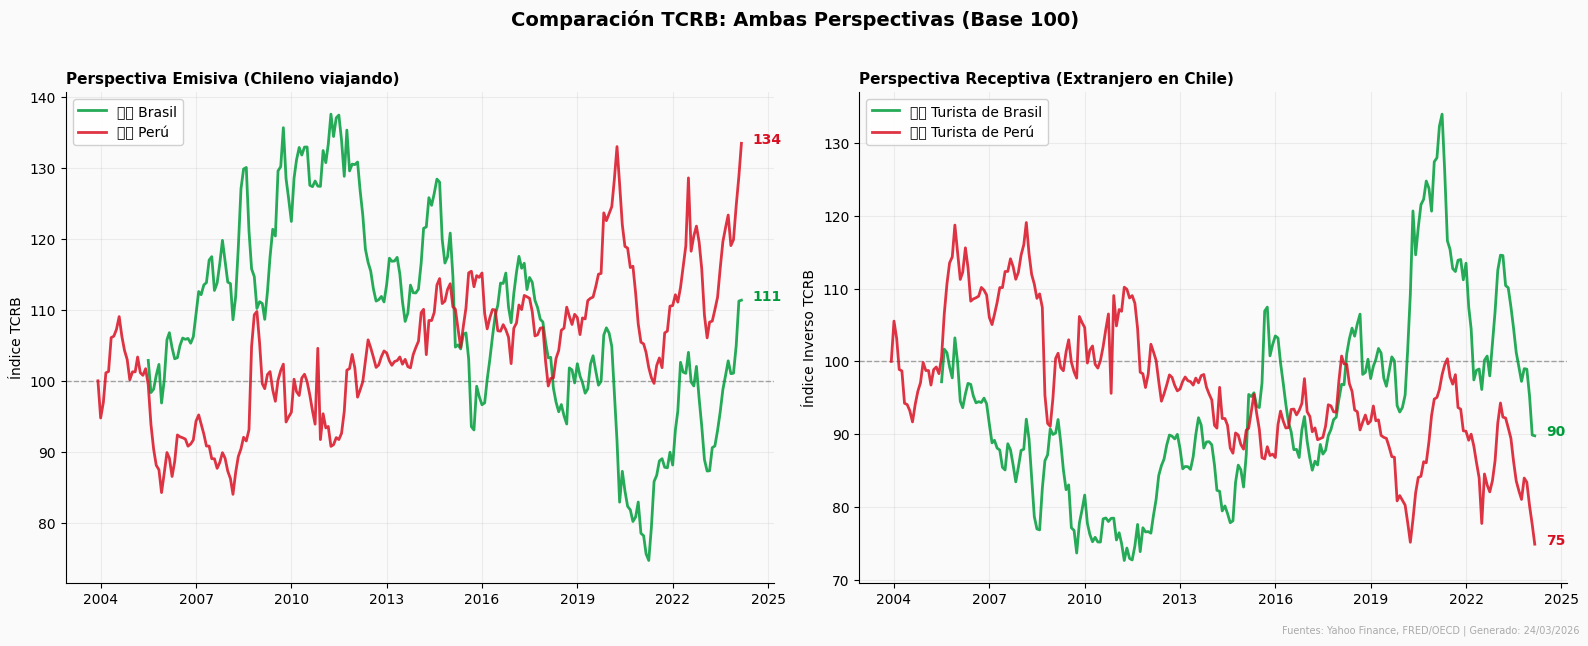

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 6: Gráfico comparativo de todos los países
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Comparación TCRB: Ambas Perspectivas (Base 100)',
             fontsize=14, fontweight='bold', y=1.02)

# ── Panel Izquierdo: Perspectiva Emisiva ──────────────────────
ax = axes[0]
ax.set_facecolor('#FAFAFA')
ax.axhline(y=100, color=COLORES['equilibrio'], linestyle='--', alpha=0.4, linewidth=1)

for pais in resultados_tcrb:
    config = PAISES_CONFIG[pais]
    col = f'TCRB_{pais}_Idx'
    serie = df[col].dropna()
    if not serie.empty:
        ax.plot(serie.index, serie.values, color=COLORES[pais]['primario'],
                linewidth=2, label=f"{config['bandera']} {pais}", alpha=0.85)
        ax.annotate(f'{serie.iloc[-1]:.0f}',
                    xy=(serie.index[-1], serie.iloc[-1]),
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=10, fontweight='bold', color=COLORES[pais]['primario'])

ax.set_title('Perspectiva Emisiva (Chileno viajando)', fontsize=11, fontweight='bold', loc='left')
ax.set_ylabel('Índice TCRB')
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.2)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Panel Derecho: Perspectiva Receptiva (1/TCRB) ────────────
ax = axes[1]
ax.set_facecolor('#FAFAFA')
ax.axhline(y=100, color=COLORES['equilibrio'], linestyle='--', alpha=0.4, linewidth=1)

for pais in resultados_tcrb:
    config = PAISES_CONFIG[pais]
    col = f'TCRB_{pais}_Idx'
    serie = df[col].dropna()
    if not serie.empty:
        serie_inv = (100 / serie) * 100
        ax.plot(serie_inv.index, serie_inv.values, color=COLORES[pais]['primario'],
                linewidth=2, label=f"{config['bandera']} Turista de {pais}", alpha=0.85,
                linestyle='-')
        ax.annotate(f'{serie_inv.iloc[-1]:.0f}',
                    xy=(serie_inv.index[-1], serie_inv.iloc[-1]),
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=10, fontweight='bold', color=COLORES[pais]['primario'])

ax.set_title('Perspectiva Receptiva (Extranjero en Chile)', fontsize=11, fontweight='bold', loc='left')
ax.set_ylabel('Índice Inverso TCRB')
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.2)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fecha_hoy = datetime.today().strftime("%d/%m/%Y")
fig.text(0.99, -0.02,
         f'Fuentes: Yahoo Finance, FRED/OECD | Generado: {fecha_hoy}',
         fontsize=7, color='#AAA', ha='right')
plt.tight_layout()
plt.show()

## 7. Descomposición del TCRB: Efecto Cambiario vs. Efecto Inflación
Análisis de qué componente impulsa los cambios en competitividad: ¿el tipo de cambio nominal o el diferencial de inflación?

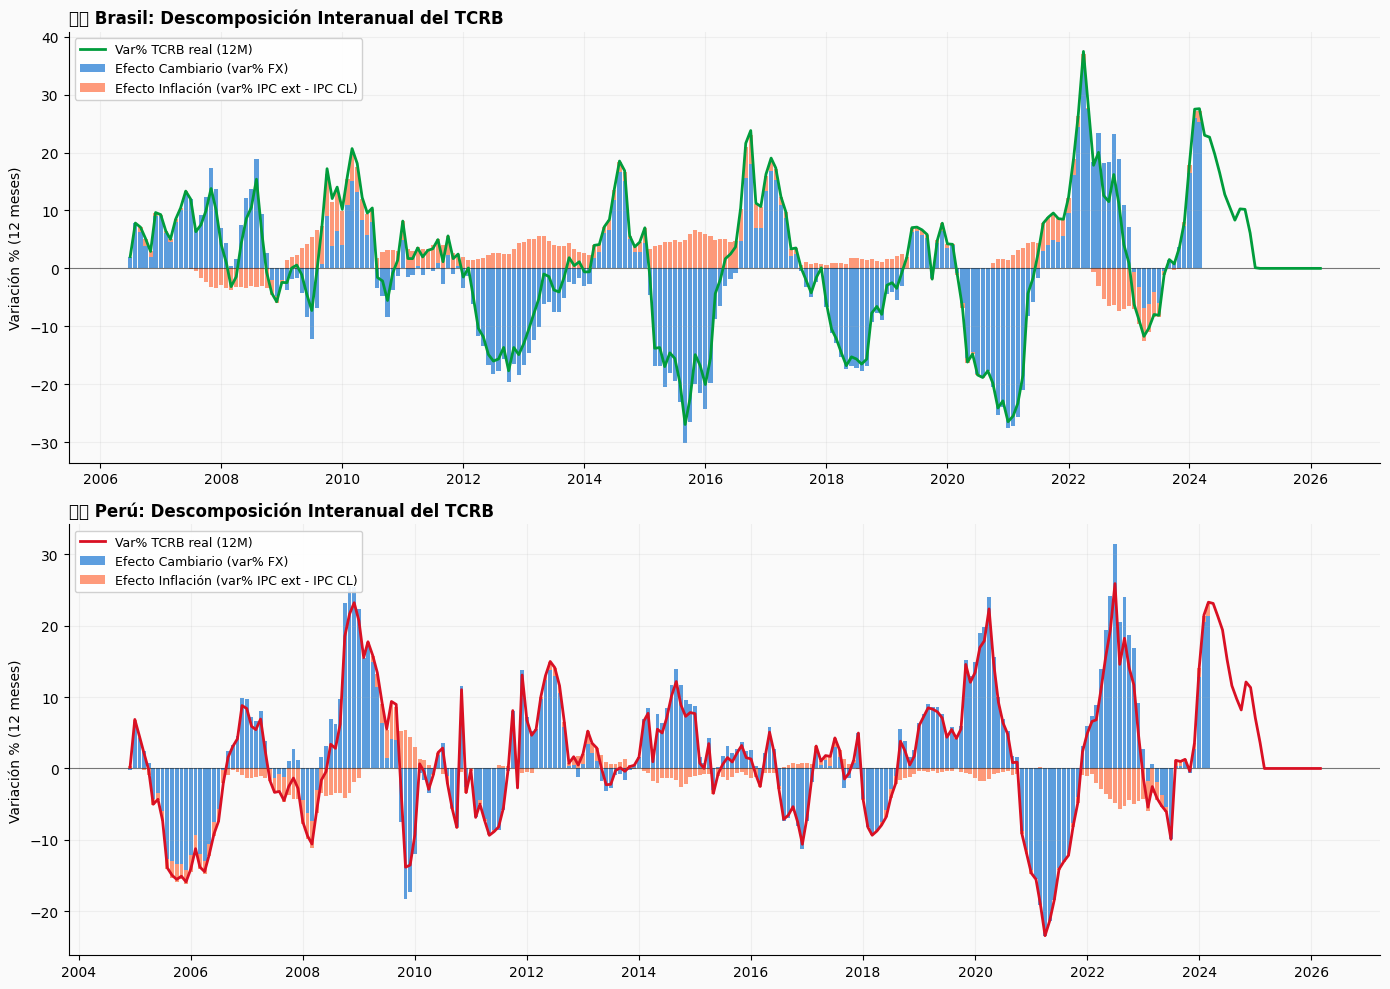

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 7: Descomposición del TCRB
# ══════════════════════════════════════════════════════════════
# El TCRB = E * P_i / P_CL. Su variación % se descompone aprox. como:
#   delta_TCRB ≈ delta_E + delta_P_i - delta_P_CL
# Esto permite ver si la competitividad cambia por tipo de cambio o por inflación.

n_paises = len(resultados_tcrb)
if n_paises > 0:
    fig, axes = plt.subplots(n_paises, 1, figsize=(14, 5 * n_paises), dpi=100, squeeze=False)
    fig.patch.set_facecolor('#FAFAFA')

    for i, pais in enumerate(resultados_tcrb):
        ax = axes[i, 0]
        ax.set_facecolor('#FAFAFA')
        config = PAISES_CONFIG[pais]

        col_fx = f'FX_{pais}'
        col_ipc_ext = f'IPC_{pais}'
        col_ipc_chl = 'IPC_CHL'

        # Variaciones % interanuales (12 meses)
        sub = df[[col_fx, col_ipc_ext, col_ipc_chl]].dropna()
        if len(sub) < 13:
            ax.text(0.5, 0.5, f'Datos insuficientes para {pais}',
                    transform=ax.transAxes, ha='center', fontsize=12)
            continue

        var_fx = sub[col_fx].pct_change(12) * 100
        var_ipc_ext = sub[col_ipc_ext].pct_change(12) * 100
        var_ipc_chl = sub[col_ipc_chl].pct_change(12) * 100

        # Componentes
        efecto_cambiario = var_fx
        efecto_inflacion = var_ipc_ext - var_ipc_chl
        var_tcrb_aprox = efecto_cambiario + efecto_inflacion

        # Gráfico de barras apiladas
        idx = var_fx.dropna().index
        width = 25  # días para el ancho de barra

        ax.bar(idx, efecto_cambiario.loc[idx], width=width, alpha=0.7,
               color='#1976D2', label='Efecto Cambiario (var% FX)')
        ax.bar(idx, efecto_inflacion.loc[idx], width=width, alpha=0.7,
               bottom=efecto_cambiario.loc[idx].clip(lower=0).where(efecto_inflacion.loc[idx] >= 0, 0) +
                      efecto_cambiario.loc[idx].clip(upper=0).where(efecto_inflacion.loc[idx] < 0, 0),
               color='#FF7043', label='Efecto Inflación (var% IPC ext - IPC CL)')

        # Línea de variación total TCRB
        col_tcrb_idx = f'TCRB_{pais}_Idx'
        if col_tcrb_idx in df.columns:
            var_tcrb_real = df[col_tcrb_idx].pct_change(12) * 100
            ax.plot(var_tcrb_real.dropna().index, var_tcrb_real.dropna().values,
                    color=COLORES[pais]['primario'], linewidth=2, label='Var% TCRB real (12M)',
                    zorder=5)

        ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
        ax.set_title(f"{config['bandera']} {pais}: Descomposición Interanual del TCRB",
                     fontsize=12, fontweight='bold', loc='left')
        ax.set_ylabel('Variación % (12 meses)')
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.grid(True, alpha=0.15)
        ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay países con TCRB calculado para descomponer.")

## 8. Análisis de Estacionalidad del TCRB
Patrón mensual promedio histórico del TCRB. Útil para identificar los **meses óptimos para viajar** según competitividad cambiaria: ¿hay meses del año en que sistemáticamente conviene más viajar a Brasil o Perú?

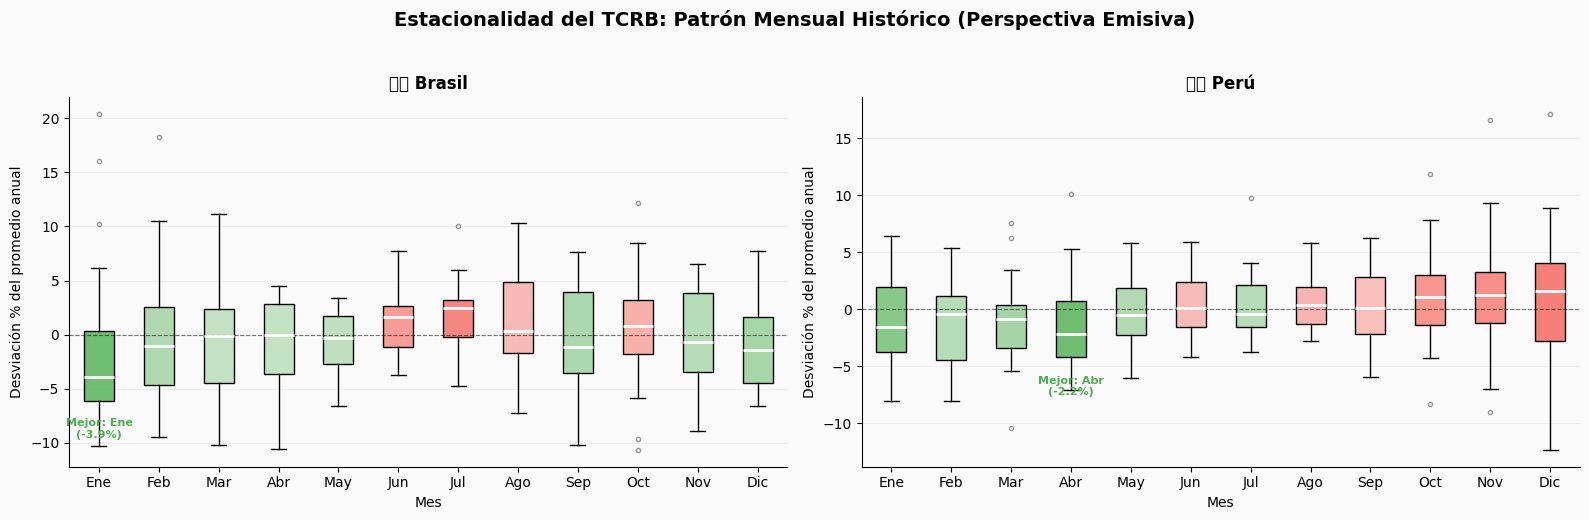

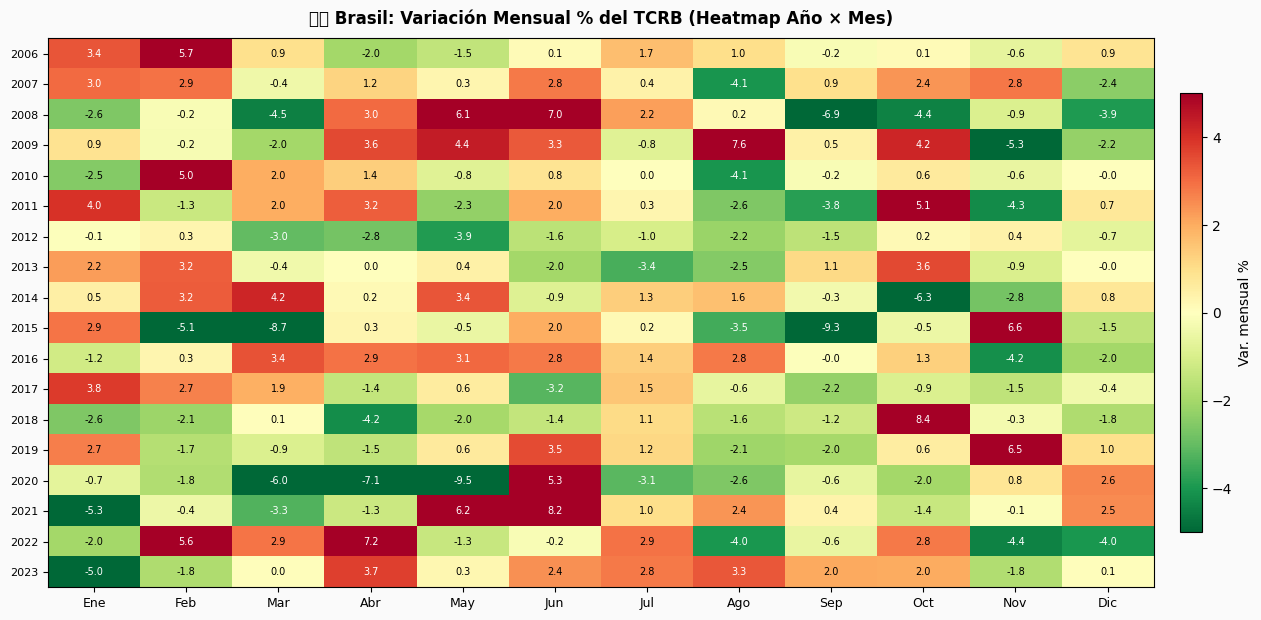

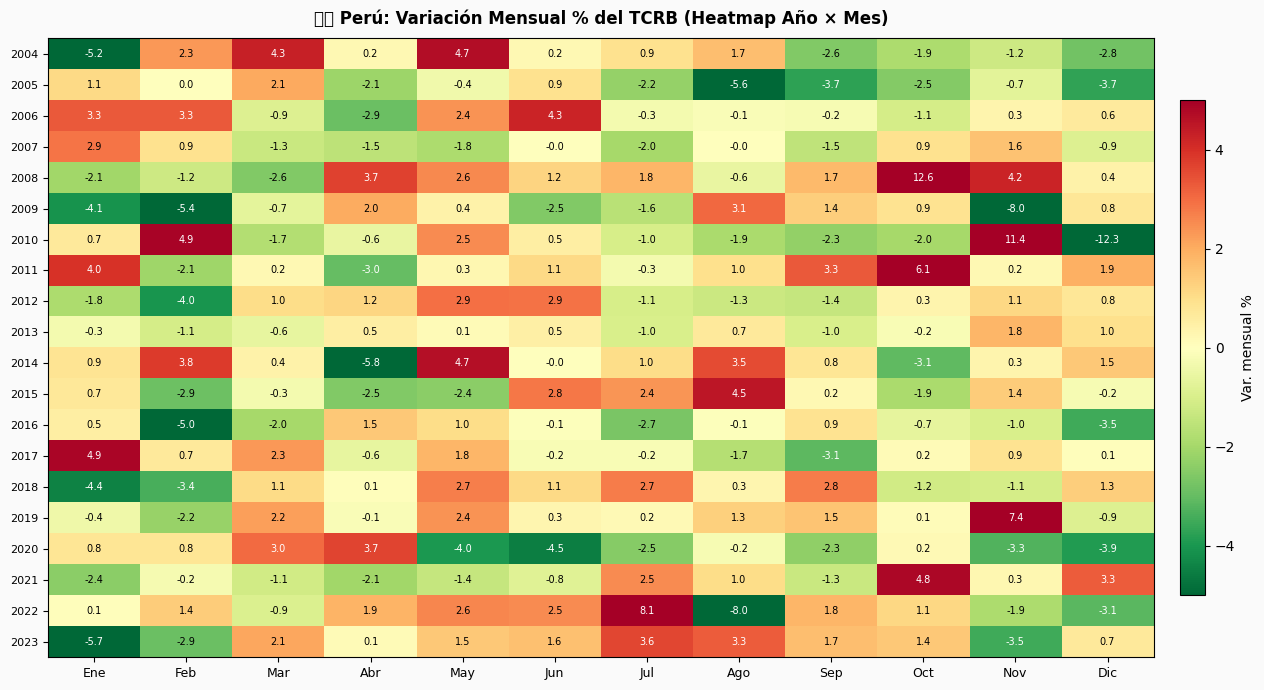

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 12: Análisis de Estacionalidad
# ══════════════════════════════════════════════════════════════

meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
            'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

n_paises_est = len(resultados_tcrb)
if n_paises_est > 0:
    fig, axes = plt.subplots(1, n_paises_est, figsize=(8 * n_paises_est, 5), dpi=100, squeeze=False)
    fig.patch.set_facecolor('#FAFAFA')
    fig.suptitle('Estacionalidad del TCRB: Patrón Mensual Histórico (Perspectiva Emisiva)',
                 fontsize=14, fontweight='bold', y=1.03)

    for i, pais in enumerate(resultados_tcrb):
        ax = axes[0, i]
        ax.set_facecolor('#FAFAFA')
        config = PAISES_CONFIG[pais]
        col = f'TCRB_{pais}_Idx'
        serie = df[col].dropna()

        if len(serie) < 24:
            ax.text(0.5, 0.5, f'Datos insuficientes para {pais}',
                    transform=ax.transAxes, ha='center')
            continue

        # Variación mensual respecto al promedio anual de cada año
        anual = serie.groupby(serie.index.year).transform('mean')
        desv_mensual = ((serie / anual) - 1) * 100  # desviación % del promedio anual

        # Agrupar por mes
        datos_por_mes = [desv_mensual[desv_mensual.index.month == m].values for m in range(1, 13)]

        # Box plot
        bp = ax.boxplot(datos_por_mes, labels=meses_es, patch_artist=True,
                        medianprops=dict(color='white', linewidth=2),
                        flierprops=dict(marker='o', markersize=3, alpha=0.4))

        # Colorear según mediana
        medianas = [np.median(d) if len(d) > 0 else 0 for d in datos_por_mes]
        max_abs = max(abs(min(medianas)), abs(max(medianas)), 1)

        for j, (patch, med) in enumerate(zip(bp['boxes'], medianas)):
            # Verde = barato (favorable), Rojo = caro (desfavorable)
            if med <= 0:
                intensidad = min(abs(med) / max_abs, 1)
                color = (0.3, 0.69, 0.31, 0.3 + 0.5 * intensidad)  # verde
            else:
                intensidad = min(med / max_abs, 1)
                color = (0.96, 0.26, 0.21, 0.3 + 0.5 * intensidad)  # rojo
            patch.set_facecolor(color)

        ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_title(f"{config['bandera']} {pais}", fontsize=12, fontweight='bold')
        ax.set_ylabel('Desviación % del promedio anual')
        ax.set_xlabel('Mes')
        ax.grid(True, alpha=0.15, axis='y')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Anotar meses más favorables
        idx_min = np.argmin(medianas)
        idx_max = np.argmax(medianas)
        ax.annotate(f'Mejor: {meses_es[idx_min]}\n({medianas[idx_min]:+.1f}%)',
                    xy=(idx_min + 1, medianas[idx_min]),
                    xytext=(0, -30), textcoords='offset points',
                    fontsize=8, color=COLORES['favorable'], fontweight='bold',
                    ha='center', va='top')

    plt.tight_layout()
    plt.show()

    # ── Heatmap: Variación mensual por año ────────────────────
    for pais in resultados_tcrb:
        config = PAISES_CONFIG[pais]
        col = f'TCRB_{pais}_Idx'
        serie = df[col].dropna()

        if len(serie) < 24:
            continue

        # Crear tabla pivote: año × mes con variación mensual %
        serie_var = serie.pct_change() * 100
        pivot = pd.DataFrame({
            'Año': serie_var.index.year,
            'Mes': serie_var.index.month,
            'Var': serie_var.values
        }).pivot_table(index='Año', columns='Mes', values='Var', aggfunc='mean')

        # Filtrar años con al menos 6 meses de datos
        pivot = pivot[pivot.notna().sum(axis=1) >= 6]
        pivot.columns = meses_es

        if pivot.empty:
            continue

        fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.35)), dpi=100)
        fig.patch.set_facecolor('#FAFAFA')

        # Pintar heatmap manualmente con imshow
        data = pivot.values
        im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto',
                       vmin=-5, vmax=5, interpolation='nearest')

        ax.set_xticks(range(12))
        ax.set_xticklabels(meses_es, fontsize=9)
        ax.set_yticks(range(len(pivot)))
        ax.set_yticklabels(pivot.index.astype(int), fontsize=8)

        # Anotar valores
        for yi in range(data.shape[0]):
            for xi in range(data.shape[1]):
                val = data[yi, xi]
                if not np.isnan(val):
                    color_txt = 'white' if abs(val) > 3 else 'black'
                    ax.text(xi, yi, f'{val:.1f}', ha='center', va='center',
                            fontsize=7, color=color_txt)

        ax.set_title(f"{config['bandera']} {pais}: Variación Mensual % del TCRB (Heatmap Año × Mes)",
                     fontsize=12, fontweight='bold', pad=10)
        plt.colorbar(im, ax=ax, label='Var. mensual %', shrink=0.8, pad=0.02)
        plt.tight_layout()
        plt.show()

else:
    print("⚠️ No hay datos para analizar estacionalidad.")

## 9. Análisis de Volatilidad del TCRB
La volatilidad mide la **incertidumbre cambiaria** para el turista. Un TCRB volátil implica que el costo real de un viaje puede cambiar significativamente en pocas semanas, lo que afecta la planificación y el presupuesto.

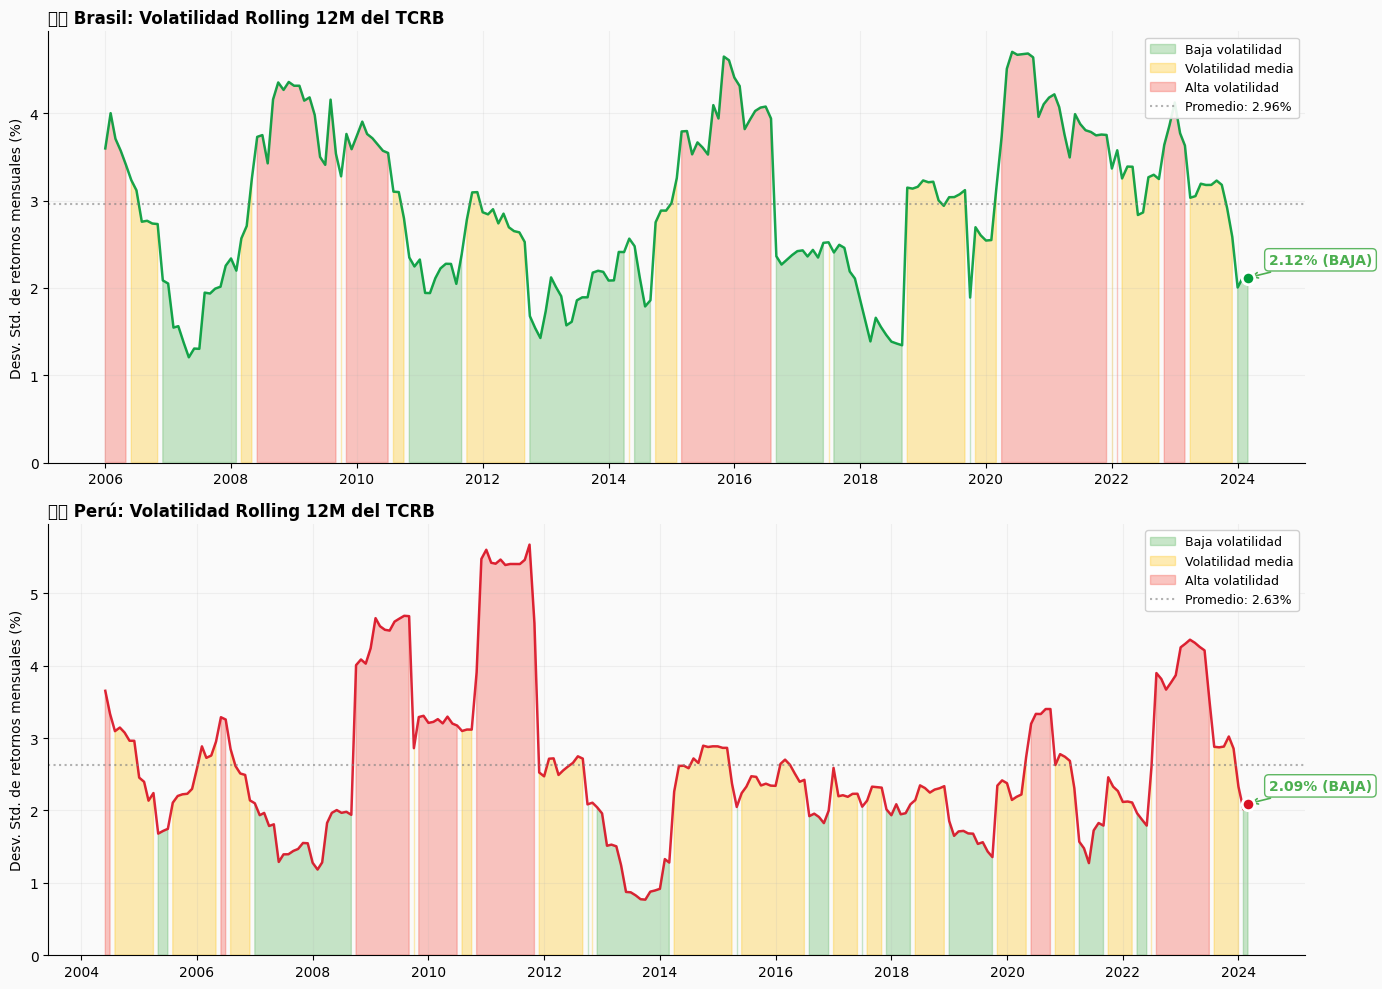


📊 Resumen de Volatilidad Actual:
   🇧🇷 Brasil: 2.12% (promedio histórico: 2.96%, ratio actual/promedio: 0.72x)
   🇵🇪 Perú: 2.09% (promedio histórico: 2.63%, ratio actual/promedio: 0.80x)


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 13: Análisis de Volatilidad
# ══════════════════════════════════════════════════════════════

n_paises_vol = len(resultados_tcrb)
if n_paises_vol > 0:
    fig, axes = plt.subplots(n_paises_vol, 1, figsize=(14, 5 * n_paises_vol), dpi=100, squeeze=False)
    fig.patch.set_facecolor('#FAFAFA')

    for i, pais in enumerate(resultados_tcrb):
        ax = axes[i, 0]
        ax.set_facecolor('#FAFAFA')
        config = PAISES_CONFIG[pais]
        col = f'TCRB_{pais}_Idx'
        serie = df[col].dropna()

        if len(serie) < 24:
            ax.text(0.5, 0.5, f'Datos insuficientes para {pais}',
                    transform=ax.transAxes, ha='center')
            continue

        # Retornos mensuales %
        retornos = serie.pct_change().dropna() * 100

        # Volatilidad rolling (desviación estándar de retornos en ventana de 12M)
        vol_12m = retornos.rolling(window=12, min_periods=6).std()

        # Bandas de régimen: baja / media / alta volatilidad
        vol_media = vol_12m.mean()
        vol_std = vol_12m.std()
        umbral_bajo = vol_media - 0.5 * vol_std
        umbral_alto = vol_media + 0.5 * vol_std

        # Graficar
        ax.fill_between(vol_12m.index, 0, vol_12m.values,
                        where=vol_12m.values <= umbral_bajo,
                        color=COLORES['favorable'], alpha=0.3, label='Baja volatilidad')
        ax.fill_between(vol_12m.index, 0, vol_12m.values,
                        where=(vol_12m.values > umbral_bajo) & (vol_12m.values <= umbral_alto),
                        color='#FFC107', alpha=0.3, label='Volatilidad media')
        ax.fill_between(vol_12m.index, 0, vol_12m.values,
                        where=vol_12m.values > umbral_alto,
                        color=COLORES['desfavorable'], alpha=0.3, label='Alta volatilidad')

        ax.plot(vol_12m.index, vol_12m.values, color=COLORES[pais]['primario'],
                linewidth=1.8, alpha=0.9)

        # Líneas de referencia
        ax.axhline(y=vol_media, color='gray', linestyle=':', alpha=0.6,
                    label=f'Promedio: {vol_media:.2f}%')

        # Anotar el valor actual
        ultimo = vol_12m.dropna().iloc[-1]
        ultimo_fecha = vol_12m.dropna().index[-1]
        regimen = 'BAJA' if ultimo <= umbral_bajo else 'ALTA' if ultimo > umbral_alto else 'MEDIA'
        color_regimen = COLORES['favorable'] if regimen == 'BAJA' else COLORES['desfavorable'] if regimen == 'ALTA' else '#FFC107'

        ax.scatter([ultimo_fecha], [ultimo], color=COLORES[pais]['primario'], s=80,
                   zorder=5, edgecolors='white', linewidth=2)
        ax.annotate(f'{ultimo:.2f}% ({regimen})',
                    xy=(ultimo_fecha, ultimo), xytext=(15, 10),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    color=color_regimen,
                    arrowprops=dict(arrowstyle='->', color=color_regimen, lw=1.2),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor=color_regimen, alpha=0.9))

        ax.set_title(f"{config['bandera']} {pais}: Volatilidad Rolling 12M del TCRB",
                     fontsize=12, fontweight='bold', loc='left')
        ax.set_ylabel('Desv. Std. de retornos mensuales (%)')
        ax.set_xlabel('')
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.grid(True, alpha=0.15)
        ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

    # ── Resumen de volatilidad ────────────────────────────────
    print("\n📊 Resumen de Volatilidad Actual:")
    for pais in resultados_tcrb:
        config = PAISES_CONFIG[pais]
        col = f'TCRB_{pais}_Idx'
        serie = df[col].dropna()
        if len(serie) < 24:
            continue
        retornos = serie.pct_change().dropna() * 100
        vol_12m = retornos.rolling(window=12, min_periods=6).std()
        ultimo = vol_12m.dropna().iloc[-1]
        prom = vol_12m.mean()
        ratio = ultimo / prom if prom > 0 else float('nan')
        print(f"   {config['bandera']} {pais}: {ultimo:.2f}% "
              f"(promedio histórico: {prom:.2f}%, "
              f"ratio actual/promedio: {ratio:.2f}x)")
else:
    print("⚠️ No hay datos para analizar volatilidad.")

## 10. Correlación entre Destinos
¿Se mueven juntos los TCRB de Brasil y Perú? Si están altamente correlacionados, ambos destinos ganan o pierden competitividad al mismo tiempo (probablemente por movimientos del peso chileno). Si la correlación es baja, hay oportunidades de sustitución entre destinos.

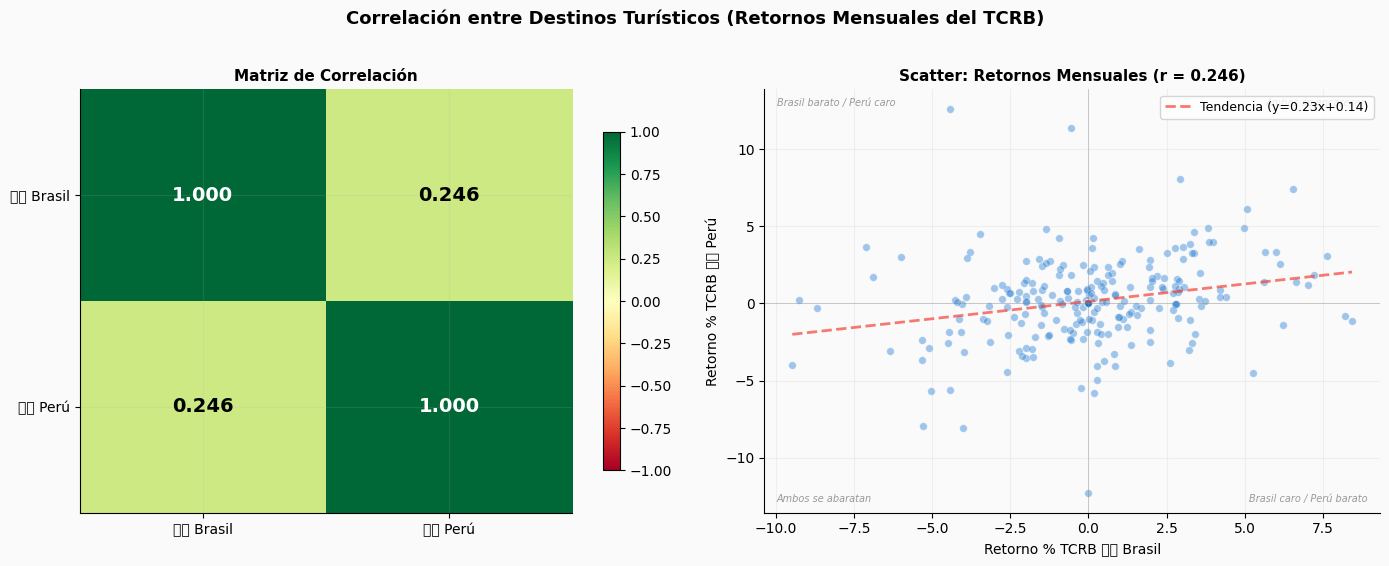

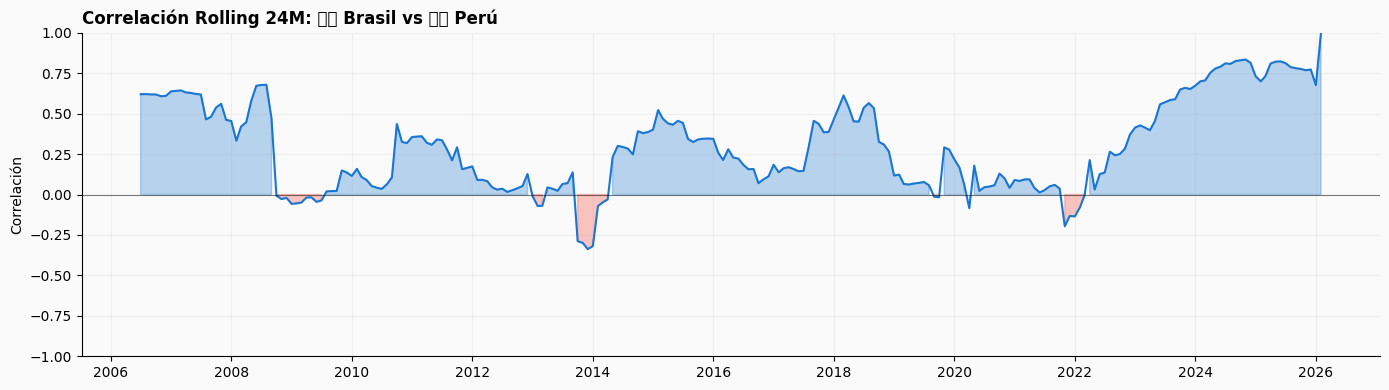

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 14: Análisis de Correlación entre Destinos
# ══════════════════════════════════════════════════════════════

paises_con_datos = list(resultados_tcrb.keys())

if len(paises_con_datos) >= 2:
    # ── Matriz de correlación de retornos ─────────────────────
    retornos_df = pd.DataFrame()
    for pais in paises_con_datos:
        col = f'TCRB_{pais}_Idx'
        retornos_df[pais] = df[col].pct_change() * 100

    retornos_df = retornos_df.dropna()

    corr_matrix = retornos_df.corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=100)
    fig.patch.set_facecolor('#FAFAFA')
    fig.suptitle('Correlación entre Destinos Turísticos (Retornos Mensuales del TCRB)',
                 fontsize=13, fontweight='bold', y=1.02)

    # ── Panel 1: Heatmap de correlación ───────────────────────
    ax = axes[0]
    ax.set_facecolor('#FAFAFA')
    n = len(paises_con_datos)
    im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    labels = [f"{PAISES_CONFIG[p]['bandera']} {p}" for p in paises_con_datos]
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)

    for yi in range(n):
        for xi in range(n):
            val = corr_matrix.values[yi, xi]
            color_txt = 'white' if abs(val) > 0.6 else 'black'
            ax.text(xi, yi, f'{val:.3f}', ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color_txt)

    ax.set_title('Matriz de Correlación', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)

    # ── Panel 2: Scatter plot (si hay exactamente 2 países) ──
    ax = axes[1]
    ax.set_facecolor('#FAFAFA')

    if len(paises_con_datos) == 2:
        p1, p2 = paises_con_datos
        x_data = retornos_df[p1].values
        y_data = retornos_df[p2].values

        ax.scatter(x_data, y_data, alpha=0.4, s=30, color='#1976D2', edgecolors='white', linewidth=0.5)

        # Línea de tendencia
        z = np.polyfit(x_data, y_data, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_data.min(), x_data.max(), 100)
        ax.plot(x_line, p(x_line), color=COLORES['desfavorable'], linewidth=2,
                linestyle='--', alpha=0.7, label=f'Tendencia (y={z[0]:.2f}x{z[1]:+.2f})')

        ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.5)
        ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.5)

        corr_val = corr_matrix.loc[p1, p2]
        ax.set_xlabel(f'Retorno % TCRB {PAISES_CONFIG[p1]["bandera"]} {p1}', fontsize=10)
        ax.set_ylabel(f'Retorno % TCRB {PAISES_CONFIG[p2]["bandera"]} {p2}', fontsize=10)
        ax.set_title(f'Scatter: Retornos Mensuales (r = {corr_val:.3f})', fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)

        # Cuadrantes interpretativos
        ax.text(0.98, 0.98, 'Ambos se encarecen', transform=ax.transAxes,
                fontsize=7, color='#999', ha='right', va='top', style='italic')
        ax.text(0.02, 0.02, 'Ambos se abaratan', transform=ax.transAxes,
                fontsize=7, color='#999', ha='left', va='bottom', style='italic')
        ax.text(0.98, 0.02, f'{p1} caro / {p2} barato', transform=ax.transAxes,
                fontsize=7, color='#999', ha='right', va='bottom', style='italic')
        ax.text(0.02, 0.98, f'{p1} barato / {p2} caro', transform=ax.transAxes,
                fontsize=7, color='#999', ha='left', va='top', style='italic')
    else:
        # Si hay más de 2 países, mostrar rolling correlation entre todos los pares
        import itertools
        pares = list(itertools.combinations(paises_con_datos, 2))
        for p1, p2 in pares:
            roll_corr = retornos_df[p1].rolling(24, min_periods=12).corr(retornos_df[p2])
            ax.plot(roll_corr.dropna().index, roll_corr.dropna().values,
                    linewidth=1.8, label=f'{p1} vs {p2}')
        ax.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
        ax.set_title('Correlación Rolling 24M', fontsize=11, fontweight='bold')
        ax.set_ylabel('Correlación')
        ax.legend(fontsize=9)

    for a in axes:
        a.grid(True, alpha=0.15)
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    # ── Correlación rolling bilateral ─────────────────────────
    if len(paises_con_datos) == 2:
        p1, p2 = paises_con_datos
        roll_corr = retornos_df[p1].rolling(24, min_periods=12).corr(retornos_df[p2])

        fig, ax = plt.subplots(figsize=(14, 4), dpi=100)
        fig.patch.set_facecolor('#FAFAFA')
        ax.set_facecolor('#FAFAFA')

        ax.fill_between(roll_corr.dropna().index, 0, roll_corr.dropna().values,
                        where=roll_corr.dropna().values >= 0, color='#1976D2', alpha=0.3)
        ax.fill_between(roll_corr.dropna().index, 0, roll_corr.dropna().values,
                        where=roll_corr.dropna().values < 0, color=COLORES['desfavorable'], alpha=0.3)
        ax.plot(roll_corr.dropna().index, roll_corr.dropna().values, color='#1976D2', linewidth=1.5)

        ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
        ax.set_title(f'Correlación Rolling 24M: {PAISES_CONFIG[p1]["bandera"]} {p1} vs {PAISES_CONFIG[p2]["bandera"]} {p2}',
                     fontsize=12, fontweight='bold', loc='left')
        ax.set_ylabel('Correlación')
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.set_ylim(-1, 1)
        ax.grid(True, alpha=0.15)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

else:
    print("ℹ️ Se necesitan al menos 2 países para analizar correlación.")

## 11. Tabla de Datos: Últimos 12 Meses
Vista tabular con los valores más recientes del TCRB y sus componentes.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 8: Tabla resumen últimos 12 meses
# ══════════════════════════════════════════════════════════════

cols_tabla = ['IPC_CHL']
for pais in resultados_tcrb:
    cols_tabla.extend([f'FX_{pais}', f'IPC_{pais}', f'TCRB_{pais}_Idx'])

df_tabla = df[cols_tabla].dropna(how='all').tail(12).copy()

# Renombrar columnas para legibilidad
rename_map = {'IPC_CHL': 'IPC Chile'}
for pais in resultados_tcrb:
    cfg = PAISES_CONFIG[pais]
    rename_map[f'FX_{pais}'] = f'FX {cfg["moneda"]}/CLP'
    rename_map[f'IPC_{pais}'] = f'IPC {pais}'
    rename_map[f'TCRB_{pais}_Idx'] = f'TCRB {pais}'

df_tabla = df_tabla.rename(columns=rename_map)
df_tabla.index = df_tabla.index.strftime('%Y-%m')
df_tabla.index.name = 'Mes'

# Aplicar resaltado condicional a columnas TCRB
def resaltar_tcrb(val):
    if pd.isna(val):
        return ''
    if val > 105:
        return 'background-color: #FFCDD2'  # rojo suave
    elif val < 95:
        return 'background-color: #C8E6C9'  # verde suave
    return ''

tcrb_cols = [c for c in df_tabla.columns if c.startswith('TCRB')]

styled = df_tabla.style\
    .format('{:.2f}', na_rep='–')\
    .applymap(resaltar_tcrb, subset=tcrb_cols)\
    .set_caption('Últimos 12 meses de datos disponibles')\
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#0039A6'), ('color', 'white'), ('padding', '8px'), ('font-size', '11px')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'right'), ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f8f8f8')]},
    ])

display(styled)

,IPC Chile,FX BRL/CLP,IPC Brasil,TCRB Brasil,FX PEN/CLP,IPC Perú,TCRB Perú
Mes,,,,,,,
2025-04,–,166.25,168.82,–,260.75,–,–
2025-05,–,166.13,168.82,–,260.73,–,–
2025-06,–,168.77,168.82,–,261.20,–,–
2025-07,–,171.99,168.82,–,268.30,–,–
2025-08,–,177.11,–,–,274.13,–,–
2025-09,–,178.66,–,–,276.23,–,–
2025-10,–,176.86,–,–,279.94,–,–
2025-11,–,175.12,–,–,279.57,–,–
2025-12,–,167.95,–,–,273.98,–,–


## 12. Resumen Estadístico
Tabla consolidada con estadísticas descriptivas del TCRB por país.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 9: Resumen Estadístico Consolidado
# ══════════════════════════════════════════════════════════════

resumen_rows = []
for pais, stats in resultados_tcrb.items():
    cfg = PAISES_CONFIG[pais]
    # Calcular estadísticas adicionales
    col_idx = f'TCRB_{pais}_Idx'
    serie = df[col_idx].dropna()

    # Percentil actual
    val_actual = stats['actual']
    percentil = (serie < val_actual).mean() * 100

    # Tendencia: pendiente de regresión lineal sobre últimos 24 meses
    ultimos_24 = serie.tail(24)
    if len(ultimos_24) >= 12:
        x = np.arange(len(ultimos_24))
        slope = np.polyfit(x, ultimos_24.values, 1)[0]
        tendencia = 'Alcista' if slope > 0.1 else 'Bajista' if slope < -0.1 else 'Estable'
    else:
        tendencia = 'N/D'

    resumen_rows.append({
        'País': f"{cfg['bandera']} {pais}",
        'Moneda': cfg['moneda'],
        'Desde': stats['desde'],
        'Hasta': stats['hasta'],
        'Obs.': stats['obs'],
        'Actual': round(stats['actual'], 1),
        'Media': round(stats['media'], 1),
        'Desv.Std': round(stats['desv'], 1),
        'Mínimo': round(stats['min'], 1),
        'Máximo': round(stats['max'], 1),
        'Var.12M': f"{stats['var_12m']:+.1f}%" if not np.isnan(stats['var_12m']) else 'N/D',
        'Percentil': f"{percentil:.0f}%",
        'Tendencia 24M': tendencia,
    })

df_resumen = pd.DataFrame(resumen_rows)
df_resumen = df_resumen.set_index('País')

styled_resumen = df_resumen.style\
    .set_caption('Resumen Estadístico del TCRB por País')\
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#0039A6'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]},
    ])

display(styled_resumen)

,Moneda,Desde,Hasta,Obs.,Actual,Media,Desv.Std,Mínimo,Máximo,Var.12M,Percentil,Tendencia 24M
País,,,,,,,,,,,,
🇧🇷 Brasil,BRL,2005-07,2024-03,225,111.400000,109.000000,14.100000,74.600000,137.600000,+27.6%,56%,Alcista
🇵🇪 Perú,PEN,2003-12,2024-03,244,133.500000,104.600000,9.900000,84.000000,133.500000,+23.3%,100%,Alcista


## 13. Diagnóstico y Validación de Datos
Chequeo automático de integridad, gaps, outliers y coherencia entre fuentes.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 15: Diagnóstico y Validación de Datos
# ══════════════════════════════════════════════════════════════

print("=" * 60)
print("DIAGNÓSTICO DE CALIDAD DE DATOS")
print("=" * 60)

alertas = []

for pais in resultados_tcrb:
    config = PAISES_CONFIG[pais]
    print(f"\n{config['bandera']} {pais}:")

    # ── 1. Gaps (meses faltantes) ─────────────────────────────
    col_idx = f'TCRB_{pais}_Idx'
    serie = df[col_idx].dropna()
    if len(serie) > 1:
        # Detectar saltos mayores a 1 mes
        diffs = serie.index.to_series().diff()
        gaps = diffs[diffs > pd.Timedelta(days=45)]
        if len(gaps) > 0:
            print(f"   ⚠️  {len(gaps)} gap(s) detectado(s) en la serie:")
            for fecha, delta in gaps.items():
                meses_gap = delta.days // 30
                print(f"      {fecha.strftime('%Y-%m')}: salto de ~{meses_gap} meses")
                alertas.append(f"{pais}: gap de {meses_gap} meses en {fecha.strftime('%Y-%m')}")
        else:
            print(f"   ✅ Sin gaps en la serie temporal")

    # ── 2. Outliers (valores extremos en retornos) ────────────
    retornos = serie.pct_change().dropna()
    if len(retornos) > 12:
        media_ret = retornos.mean()
        std_ret = retornos.std()
        umbral = 3 * std_ret
        outliers = retornos[abs(retornos - media_ret) > umbral]
        if len(outliers) > 0:
            print(f"   ⚠️  {len(outliers)} outlier(s) detectado(s) (>3 sigma):")
            for fecha, val in outliers.items():
                print(f"      {fecha.strftime('%Y-%m')}: retorno {val*100:+.1f}%")
                alertas.append(f"{pais}: outlier en {fecha.strftime('%Y-%m')} ({val*100:+.1f}%)")
        else:
            print(f"   ✅ Sin outliers extremos (>3 sigma)")

    # ── 3. Tendencia de actualización ─────────────────────────
    ultimo_dato = serie.index[-1]
    hoy = pd.Timestamp.today().normalize()
    dias_atraso = (hoy - ultimo_dato).days
    if dias_atraso > 60:
        print(f"   ⚠️  Último dato: {ultimo_dato.strftime('%Y-%m')} ({dias_atraso} días de atraso)")
        alertas.append(f"{pais}: datos con {dias_atraso} días de atraso")
    else:
        print(f"   ✅ Datos actualizados al {ultimo_dato.strftime('%Y-%m')}")

    # ── 4. Rango razonable del TCRB ──────────────────────────
    val_actual = serie.iloc[-1]
    val_media = serie.mean()
    val_std = serie.std()
    z_score = (val_actual - val_media) / val_std if val_std > 0 else 0

    if abs(z_score) > 2:
        print(f"   ⚠️  Valor actual ({val_actual:.1f}) está a {z_score:+.1f} desviaciones de la media")
        alertas.append(f"{pais}: TCRB actual a {z_score:+.1f} sigma de la media histórica")
    else:
        print(f"   ✅ Valor actual ({val_actual:.1f}) dentro de rango normal (z={z_score:+.1f})")

    # ── 5. Monotonía del IPC (debe ser creciente) ────────────
    col_ipc = f'IPC_{pais}'
    if col_ipc in df.columns:
        ipc_serie = df[col_ipc].dropna()
        if len(ipc_serie) > 1:
            decrementos = (ipc_serie.diff() < 0).sum()
            pct_decrementos = decrementos / len(ipc_serie) * 100
            if pct_decrementos > 10:
                print(f"   ⚠️  IPC tiene {decrementos} decrementos ({pct_decrementos:.1f}%) - verificar fuente")
                alertas.append(f"{pais}: IPC con {pct_decrementos:.1f}% decrementos")
            else:
                print(f"   ✅ IPC predominantemente creciente ({pct_decrementos:.1f}% decrementos)")

# ── Resumen de alertas ────────────────────────────────────────
print("\n" + "=" * 60)
if alertas:
    print(f"⚠️  RESUMEN: {len(alertas)} alerta(s) detectada(s):")
    for a in alertas:
        print(f"   • {a}")
else:
    print("✅ DIAGNÓSTICO COMPLETO: Todos los datos pasan las validaciones.")

print("=" * 60)

DIAGNÓSTICO DE CALIDAD DE DATOS

🇧🇷 Brasil:
   ✅ Sin gaps en la serie temporal
   ⚠️  2 outlier(s) detectado(s) (>3 sigma):
      2015-09: retorno -9.3%
      2020-05: retorno -9.5%
   ⚠️  Último dato: 2024-03 (753 días de atraso)
   ✅ Valor actual (111.4) dentro de rango normal (z=+0.2)
   ✅ IPC predominantemente creciente (4.6% decrementos)

🇵🇪 Perú:
   ✅ Sin gaps en la serie temporal
   ⚠️  3 outlier(s) detectado(s) (>3 sigma):
      2008-10: retorno +12.6%
      2010-11: retorno +11.4%
      2010-12: retorno -12.3%
   ⚠️  Último dato: 2024-03 (753 días de atraso)
   ⚠️  Valor actual (133.5) está a +2.9 desviaciones de la media
   ✅ IPC predominantemente creciente (1.4% decrementos)

⚠️  RESUMEN: 8 alerta(s) detectada(s):
   • Brasil: outlier en 2015-09 (-9.3%)
   • Brasil: outlier en 2020-05 (-9.5%)
   • Brasil: datos con 753 días de atraso
   • Perú: outlier en 2008-10 (+12.6%)
   • Perú: outlier en 2010-11 (+11.4%)
   • Perú: outlier en 2010-12 (-12.3%)
   • Perú: datos con 753 d

## 14. Exportar Datos
Guarda el DataFrame completo como CSV para análisis externo o importación a otras herramientas.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELDA 10: Exportación de datos
# ══════════════════════════════════════════════════════════════
paises_str = '_'.join(resultados_tcrb.keys())
fecha_str = datetime.today().strftime('%Y%m%d')
nombre_archivo = f"TCRB_Chile_{paises_str}_{fecha_str}.csv"

df.to_csv(nombre_archivo, float_format='%.4f')
print(f"📁 Archivo exportado: {nombre_archivo}")
print(f"   Filas: {len(df)} | Columnas: {len(df.columns)}")
print(f"   Columnas: {', '.join(df.columns.tolist())}")

# En Google Colab, descargar automáticamente:
try:
    from google.colab import files
    files.download(nombre_archivo)
    print("   ⬇️  Descarga iniciada automáticamente.")
except ImportError:
    print("   ℹ️  Para descargar: usa el explorador de archivos de Colab (panel izquierdo).")

📁 Archivo exportado: TCRB_Chile_Brasil_Perú_20260324.csv
   Filas: 315 | Columnas: 11
   Columnas: IPC_CHL, FX_Brasil, IPC_Brasil, FX_Perú, IPC_Perú, TCRB_Brasil_Raw, TCRB_Brasil_Idx, TCRB_Brasil_MA12, TCRB_Perú_Raw, TCRB_Perú_Idx, TCRB_Perú_MA12


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ⬇️  Descarga iniciada automáticamente.


## 🚀 Próximos Pasos

### Integración con API del Banco Central de Chile
```python
# Ejemplo de integración futura (requiere credenciales):
# from bcch import BancoCentralAPI
# api = BancoCentralAPI(user='...', password='...')
# dolar_obs = api.get_series('F073.TCO.PRE.Z.D')     # Dólar Observado diario
# ipc_chl   = api.get_series('F074.IPC.IND.Z.EP09.C.M')  # IPC Chile mensual
```

### Ampliación de Países
Para agregar un nuevo país, solo se necesita extender el diccionario `PAISES_CONFIG`:
```python
PAISES_CONFIG['Argentina'] = {
    'moneda': 'ARS',
    'fx_ticker_directo': 'ARSCLP=X',
    'fx_ticker_cross': ('ARSUSD=X', 'CLP=X'),
    'ipc_fred_series': ['ARGCPIALLMINMEI'],
    'bandera': '🇦🇷',
}
PAISES_CONFIG['Colombia'] = {
    'moneda': 'COP',
    'fx_ticker_directo': None,
    'fx_ticker_cross': ('COPUSD=X', 'CLP=X'),
    'ipc_fred_series': ['COLCPIALLMINMEI'],
    'bandera': '🇨🇴',
}
PAISES_CONFIG['México'] = {
    'moneda': 'MXN',
    'fx_ticker_directo': None,
    'fx_ticker_cross': ('MXNUSD=X', 'CLP=X'),
    'ipc_fred_series': ['MEXCPIALLMINMEI'],
    'bandera': '🇲🇽',
}
```

### Mejoras Planificadas
1. **Fuente oficial BCCh**: Reemplazar Yahoo Finance por API del Banco Central como fuente primaria del dólar observado y paridades.
2. **Datos turísticos reales**: Incorporar flujos de pasajeros (SERNATUR/INE) para correlacionar TCRB con turismo efectivo.
3. **Descomposición avanzada**: Separar efecto cambiario vs. inflación diferencial (implementado en sección 6).
4. **Alertas automáticas**: Notificaciones cuando el TCRB cruce umbrales críticos (±1 desviación estándar).
5. **Migración a aplicación web**: Convertir de Colab a un dashboard en Streamlit o Dash para uso continuo.
6. **Canasta turística ponderada**: Crear un índice ponderado por flujo turístico real, no solo bilateral.